# Assignment 2: Regularization in Regression Models

Before you submit this assignment, please carefully read these submission instructions:

 - Make sure the notebook you submit is cleanly and **fully executed**. 
 - Submit your notebook back in Blackboard where you downloaded this file.
 - Submit your work as either a .ipynb Python file or a PDF file on Blackboard.
 - Please include your name in the filename.

**Goal: In this assignment, we will explore regularization techniques like Ridge, Lasso, and ElasticNet (optional) regression. The goal is to review regularization concepts through hands-on implementation of these models.**

#### Assignment Tasks

- Perform data exploration.
- Explore the data through visualizations
- Fit a baseline multiple linear regression model
- Fit Ridge regression with different alpha values
- Fit Lasso regression with different alpha values
- Analyze impact of alpha on model coefficients
- Evaluate and compare models using R-squared, RMSE
- Summarize key differences between the regularization techniques
- (Optional) Dive into elastic net and compare its performance.

#### Introduction to the Boston Housing Dataset:

For this assignment, we will be working with the Boston Housing dataset. This dataset provides an array of information related to housing prices in Boston and several predictor variables. It offers a real-world application, allowing us to explore how different factors might influence house prices. Here's a brief overview of the features:

- CRIM: Per capita crime rate by town.
- ZN: Proportion of residential land zoned for lots over 25,000 sq. ft.
- INDUS: Proportion of non-retail business acres per town.
- CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- NOX: Nitric oxide concentration (parts per 10 million).
- RM: Average number of rooms per dwelling.
- AGE: Proportion of owner-occupied units built before 1940.
- DIS: Weighted distances to five Boston employment centers.
- RAD: Index of accessibility to radial highways.
- TAX: Full-value property tax rate per $10,000.
- PTRATIO: Pupil-teacher ratio by town.

- B: 1000(Bk - 0.63)^2 where Bk is the proportion of African Americans by town
- LSTAT: Percentage of the population considered lower status.
- **MEDV**: Median value of owner-occupied homes (in $1000s).


##### Accessing the Dataset:
The Boston Housing dataset is available for download on Blackboard. Navigate to the Assignment folder for Week 2 to access the dataset.

##### Going Beyond

You are encouraged to further your analysis and experiment with the data. Additional visualizations, insights, or even diving deeper into elastic net regression will enhance your understanding and showcase your analytical prowess.

<br>

## Task 1: Load Dataset and Examine Basic Information


In [1]:
# Import packages
import pandas as pd 
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
from sklearn.model_selection import train_test_split
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

In [2]:
# Load Dataset 
df = pd.read_csv('HousingData.csv')

In [3]:
# Examine Basic Information
print(df.head())

print('dataset size')
print(df.shape)

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  
dataset size
(506, 14)


**<font color=blue>Please answer the following questions to provide basic information about the Boston Housing Dataset</font>**
- How many features does the Boston Housing Dataset contain?
  - Answer: 13
- What are the data types for each column?
  - Answer:
  - CRIM       float64
  - ZN         float64
  - INDUS      float64
  - CHAS       float64
  - NOX        float64
  - RM         float64
  - AGE        float64
  - DIS        float64
  - RAD          int64
  - TAX          int64
  - PTRATIO    float64
  - B          float64
  - LSTAT      float64
  - MEDV       float64

## Task 2: Exploratory Data Analysis (EDA): Data Visualization and Insights

##### 1. Basic Statistics:

Generate descriptive statistics

In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


##### 2. Data Distribution:

   - Plot histograms or density plots for one or some key features and the target variable `MEDV` to understand their distribution.

<Axes: xlabel='MEDV', ylabel='Count'>

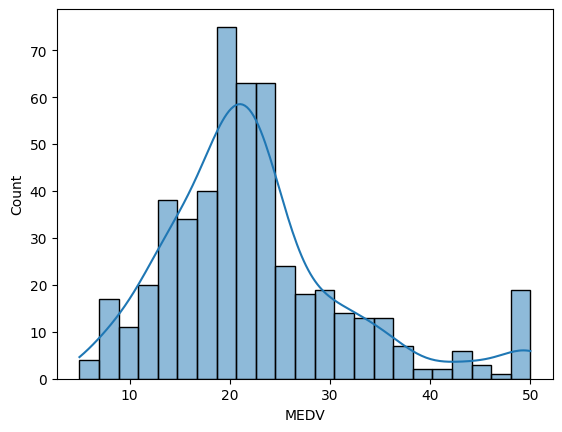

In [5]:
sns.histplot(x="MEDV", data= df, kde= True)

##### 3. Correlation Analysis:

  - Compute the correlation matrix and visualize it using a heatmap to identify features that are most correlated with the target variable `MEDV`.

<Axes: >

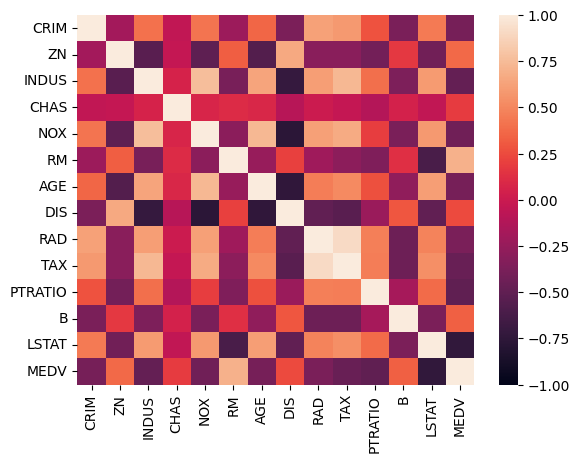

In [6]:
sns.heatmap(data = df.corr(), vmin=-1, vmax=1)

In [7]:
print(df.corr()["MEDV"].sort_values(ascending=False)[1:2])

RM    0.69536
Name: MEDV, dtype: float64


**Optional**: 4. Scatter Plots: 

- Create scatter plots for the features `RM` and `LSTAT` against `MEDV` to visualize their relationship.


*This is an optional task; completing it will allow you to observe the relationships among these variables, but you won't lose points for skipping it. Feel free to create any additional visualizations you'd like to further explore*

<Axes: xlabel='RM', ylabel='MEDV'>

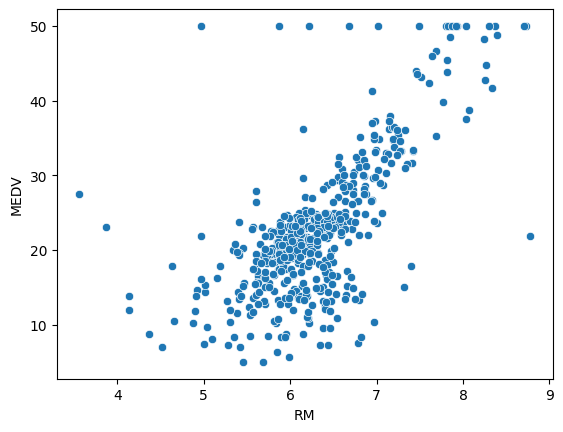

In [8]:
sns.scatterplot(x='RM',y='MEDV', data=df)

<Axes: xlabel='LSTAT', ylabel='MEDV'>

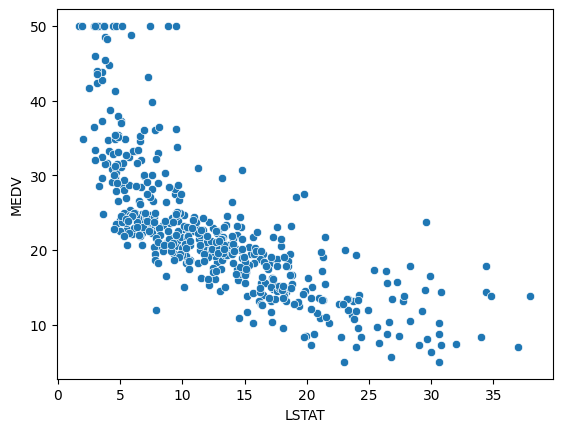

In [9]:
sns.scatterplot(x='LSTAT',y='MEDV', data=df)

In [10]:
s_cor = df.corr()[["MEDV"]].sort_values(ascending=False, by="MEDV")
s_col= s_cor.index

df_corr = pd.DataFrame(s_cor, s_col)
print(df_corr)

             MEDV
MEDV     1.000000
RM       0.695360
ZN       0.373136
B        0.333461
DIS      0.249929
CHAS     0.181391
RAD     -0.381626
CRIM    -0.391363
AGE     -0.394656
NOX     -0.427321
TAX     -0.468536
INDUS   -0.481772
PTRATIO -0.507787
LSTAT   -0.735822



### <font color=blue>Question</font>

**Write down your observations from the above visualizations: Which features seem to have a strong relationship with the target variable?**

#### Answer
 - RM has strong correlation 0.69 against MEDV
 
 - LSTAT has negative correlation relation with MEDV, it has relatively strong negative relation to 10, then it shows a bit flatter relation

## Task 3: Data Preprocessing:

We only cover handling missing values in this assisgnment. We will skip the feature scaling step for now. Once we learn about feature scaling, we will include it in the data preprocessing step. It is important to include data preprocessing like handling missing values, encoding categorical variables, treating outliers，and feature scaling in your final project to ensure the robustness and accuracy of your models.

##### Handling Missing Values

In this homework, we will remove rows containing missing values, but remember that other strategies like imputation might be more suitable in other cases.

Note: Always be cautious when dropping data. Ensure that the amount of data being dropped doesn't significantly impact the dataset's integrity.

In [11]:
# Check for missing values in each column

# df.isnull().sum()
print(df.isna().sum())

# Drop rows with missing values
df=df.dropna()



CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


**<font color=blue>Please answer this question</font>**

- Are there any missing values in the dataset? If so, how many missing values are there in each column?

  - Answer: 20 rows contain missing value

<br>

## Task 4: Train-Test Split 

Splitting the Data:

Before diving into building models, it's essential to split your dataset into a training set and a test set. This will allow you to train your models on one subset of the data and test its performance on another unseen subset.

- Split the dataset into training (70%) and testing (30%) sets.
- Use random_state=42

In [12]:
Y = df['MEDV']
X = df.drop(columns='MEDV')

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size = 0.3, random_state = 42)

## Task 5: Model Building and Evaluation

**I have provided example code for linear regression and ridge regression in this homework assignment. You may need to adjust those code samples slightly to match your own implementations based on your previous tasks.**  

**For lasso regression, you can use the linear regression and ridge regression snippets as a reference. The overall structure is similar - you need to initialize a Lasso model, fit it to training data, predict on test data, and evaluate performance.**



### 1. Multiple Linear Regression

-  #### 1). Building the Model: 

    - Start with a simple multiple linear regression model to understand the relationships between the features and the target variable.

In [14]:
#Imports the LinearRegression class from sklearn.linear_model module. 
from sklearn.linear_model import LinearRegression

#Initializes a LinearRegression object by calling the LinearRegression() constructor. 
#This creates an empty linear regression model.
linear_model = LinearRegression() 


- #### 2). Training the Model:

In [15]:
#Calls the .fit() method on the linear regression object 
#and passes the training data - X_train features and y_train labels.
linear_model.fit(X_train, y_train)

LinearRegression()

- #### 3). Model Evaluation:

After fitting the model, evaluate its performance on the test set using R2 and RMSE.

Let's briefly review some key concepts from our previous statistics courses.

- R-squared (R2):

    - Measures how much of the variation in the response/target variable is explained by the model.
    - Values range from 0 to 1. Higher is better.
    - Can be inflated by overfitting.



- RMSE:

    - Measures the average difference between predicted and actual values.
    - Shows how far off the predictions are.
    - In same units as response variable. Lower is better.


- **When to use:**

    - R2 to assess model fit. How much variance is explained.
    - RMSE to assess prediction accuracy. How close predictions are to true values.
    - Use both together to get a complete picture. R2 for fit, **RMSE for accuracy**.

In [16]:
import numpy as np

#Imports mean_squared_error and r2_score from sklearn.metrics to calculate model evaluation metrics.
from sklearn.metrics import mean_squared_error, r2_score

y_pred = linear_model.predict(X_test) #Uses the fitted linear regression model to make predictions on the test data 
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) #Calculates RMSE between true test labels y_test and predictions y_pred.
r2 = r2_score(y_test, y_pred) #Calculates R2 score between y_test and y_pred.

print(f"R^2 Score: {r2}")
print(f"RMSE: {rmse}")

R^2 Score: 0.6905175764205991
RMSE: 5.373152885248427


<br>

### 2: Ridge Regression

Ridge regression is a regularized linear regression method that adds a penalty equal to the square of the magnitude of the coefficients. This shrinks the coefficients and helps prevent overfitting.

**Part a:**
- #### 1). Building the Model:


In [17]:

from sklearn.linear_model import Ridge

# Initialize the Ridge model with default alpha value (1.0)
ridge_model = Ridge(alpha=1.0)


- #### 2). Training the Model:

In [18]:
# Fit the model on the training data
ridge_model.fit(X_train, y_train)


Ridge()

- #### 3). Model Evaluation:

In [19]:
# Predict on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Calculate the R^2 score and RMSE
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"R^2 Score for Ridge Regression: {r2_ridge}")
print(f"RMSE for Ridge Regression: {rmse_ridge}")


R^2 Score for Ridge Regression: 0.6864841424477445
RMSE for Ridge Regression: 5.408053253446232


#### Part b. Exploring the Impact of Regularization Parameter (α):

The regularization strength in Ridge Regression is controlled by the parameter α. A small α values can lead to over fitting, while a large α can lead to under-fitting.

Here, we'll train several Ridge Regression models with varying α values to observe the impact on the model coefficients. **We'll use the following α values: 0.01, 0.1, 1, 10, and 100.**

- to examine the impact of the regularization strength on the model coefficients.
- understand how the choice of α influences the model's performance, as reflected in the  R^2 and RMSE metrics.

**1). Use the following α values: 0.01, 0.1, 1, 10, and 100 to examine the impact of the regularization strength on the model coefficients.** Here are two approaches you can consider:

- **Build models individually for each α.**
- Use a `for loop` to iterate over the α values, creating and fitting models more efficiently.

In [20]:
alphas = [0.01, 0.1, 1, 10, 100] # Define alpha values to test
coefficients = [] #Create a list to store coefficients for different alphas

for a in alphas: #Loops through each alpha value defined above.
    ridge = Ridge(alpha=a) #Initializes a Ridge regression model, passing the current alpha value.
    ridge.fit(X_train, y_train)  #Fits the Ridge regression model on the training data to estimate the coefficients.
    coefficients.append(ridge.coef_) #Gets the estimated coefficients from the fitted Ridge model and appends them to the coefficients list.
print(coefficients)  #get the complete list of coefficients

[array([-1.12908735e-01,  4.50050539e-02,  5.64309550e-02,  1.17964599e+00,
       -1.70429972e+01,  4.27276541e+00, -2.01690621e-02, -1.40352331e+00,
        2.76898251e-01, -1.68158740e-02, -8.94340643e-01,  9.08141590e-03,
       -3.64802112e-01]), array([-1.12250819e-01,  4.53744915e-02,  4.75000293e-02,  1.16831663e+00,
       -1.53660456e+01,  4.28323932e+00, -2.15384522e-02, -1.38102670e+00,
        2.70717498e-01, -1.67893082e-02, -8.75956243e-01,  9.15397551e-03,
       -3.66457945e-01]), array([-1.09316246e-01,  4.72385591e-02,  6.76019379e-03,  1.09221737e+00,
       -7.74869186e+00,  4.30114368e+00, -2.75796589e-02, -1.27956987e+00,
        2.43548667e-01, -1.66987934e-02, -7.93533535e-01,  9.46403942e-03,
       -3.75956777e-01]), array([-0.10731732,  0.05140272, -0.0306467 ,  0.76740379, -1.30744721,
        3.87752003, -0.02994011, -1.19939142,  0.2326711 , -0.01700195,
       -0.73877619,  0.00941524, -0.41290037]), array([-0.10501671,  0.06082286, -0.04542761,  0.24890

### <font color=blue>Answer this Question</font>

- **How does increasing α (and thus the regularization strength) influence the importance assigned to each feature by the Ridge Regression model?**
 *support your explanations with observations from the output.*
 

- Answer: Given below coefficient chart, the coefficient of increased alpha converges into 0



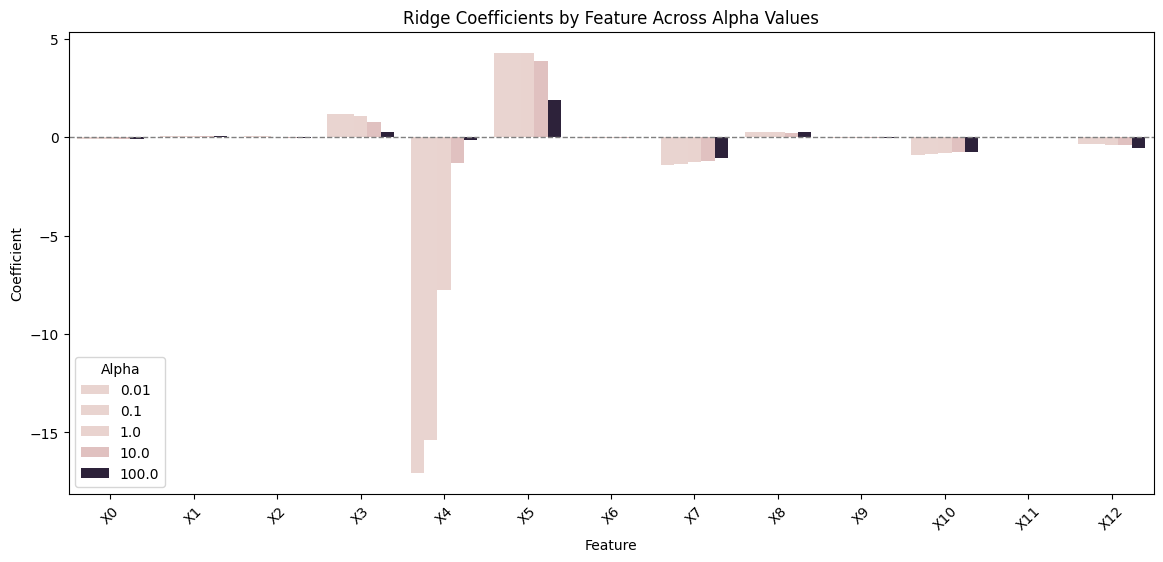

In [21]:
df_list = []
for i, coef in enumerate(coefficients):
    for j, c in enumerate(coef):
        df_list.append({'Alpha': alphas[i], 'Feature': f'X{j}', 'Coefficient': c})
df_plot = pd.DataFrame(df_list)

# Plot using seaborn
plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x="Feature", y="Coefficient", hue="Alpha")
plt.title("Ridge Coefficients by Feature Across Alpha Values")
plt.xticks(rotation=45)
plt.axhline(0, color='gray', linewidth=1, linestyle='--')

**2). Use the following α values: 0.01, 0.1, 1, 10, and 100 to evaluate Model Performance for Different α Values as reflected in the  R^2 and RMSE metrics.**

In [22]:
from sklearn.metrics import r2_score, mean_squared_error

# Create empty lists to store R^2 and RMSE scores for each alpha value tried.
r2_scores = []
rmse_scores = []


for a in alphas: #Loop through a list of alpha values
    ridge = Ridge(alpha=a)  #For each alpha, create a Ridge regression model with that alpha
    ridge.fit(X_train, y_train) #Fit it to the training data.
    y_pred = ridge.predict(X_test) #Use the fitted model to make predictions on the test data.
    
    r2_scores.append(r2_score(y_test, y_pred)) #Calculate R^2 and append to r2_scores list
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred))) #Calculate RMSE and append to rmse_scores list

# Print the scores for each alpha
for a, r2, rmse in zip(alphas, r2_scores, rmse_scores): #Loop through alphas, r2_scores and rmse_scores together. The zip() function packages them together into an iterator of tuples.
    print(f"For alpha = {a}, R^2 = {r2:.3f} and RMSE = {rmse:.3f}")



For alpha = 0.01, R^2 = 0.690 and RMSE = 5.373
For alpha = 0.1, R^2 = 0.690 and RMSE = 5.376
For alpha = 1, R^2 = 0.686 and RMSE = 5.408
For alpha = 10, R^2 = 0.677 and RMSE = 5.486
For alpha = 100, R^2 = 0.650 and RMSE = 5.715


### <font color=blue>Answer these Questions</font>

- **Which α value gives the highest R^2 score?**
  - Answer: alpha 0.1 or 0.01
- **Which α value gives the lowest RMSE?**
  - Answer: 0.01
- **Based on the above analyses, which α value would you recommend for this dataset? Why?**
  - Answer: Given Higher R^2 and Lower RMSE, alpha 0.01

<br>

### 3: Lasso Regression

Lasso regression, like Ridge regression, is a type of linear regression that includes a regularization term. The key difference is the type of penalty: Lasso regression adds a penalty equal to the absolute value of the magnitude of coefficients. This can result in feature selection wherein some of the coefficients become exactly zero.

**Part a:**
#### 1). Building the Lasso Model:

In [23]:
# Initialize the Lasso model with default alpha value (1.0)


from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)




#### 2). Training the Model:

In [24]:
# Fit the Lasso model on the training data

lasso_model.fit(X_train, y_train)

Lasso()

#### 3). Model Evaluation:
Once the model is trained, predict on the test set and evaluate its performance using the R^2 and RMSE metrics.

In [ ]:

# Predict on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Calculate the R^2 score and RMSE
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"R^2 Score for Ridge Regression: {r2_lasso}")
print(f"RMSE for Ridge Regression: {rmse_lasso}")



R^2 Score for Ridge Regression: 0.6149745156582791
RMSE for Ridge Regression: 5.993160952713364


#### Part B:  Investigating the Impact of Regularization Parameter (α) in Lasso Regression:
Here, we'll train several Lasso Regression models with varying α values to observe the impact on the model coefficients. **We'll use the following α values: 0.01, 0.1, 1, 10, and 100.**


#### 1) Use a range of α values to observe the influence on the model coefficients and performance.

In [26]:
alphas = [0.01, 0.1, 1, 10, 100] # Define alpha values to test
coefficients = [] #Create a list to store coefficients for different alphas

for a in alphas: #Loops through each alpha value defined above.
    lasso = Lasso(alpha=a) #Initializes a Ridge regression model, passing the current alpha value.
    lasso.fit(X_train, y_train)  #Fits the Ridge regression model on the training data to estimate the coefficients.
    coefficients.append(lasso.coef_) #Gets the estimated coefficients from the fitted Ridge model and appends them to the coefficients list.
print(coefficients)  #get the complete list of coefficients

[array([-1.11700032e-01,  4.58058050e-02,  3.90433886e-02,  1.00951982e+00,
       -1.37856831e+01,  4.27724354e+00, -2.24961109e-02, -1.35789525e+00,
        2.65428212e-01, -1.67836584e-02, -8.58307846e-01,  9.23204204e-03,
       -3.69428743e-01]), array([-0.10565228,  0.05027953, -0.02088009,  0.        , -0.        ,
        4.15617632, -0.03067695, -1.13541762,  0.22144721, -0.01710572,
       -0.70378117,  0.00980436, -0.39998337]), array([-0.07748045,  0.05797981, -0.        ,  0.        , -0.        ,
        1.19179125,  0.        , -0.67122665,  0.19265878, -0.01606753,
       -0.63856044,  0.00694481, -0.58663228]), array([-0.        ,  0.04969327, -0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.        ,  0.        , -0.01436185,
       -0.        ,  0.00653828, -0.42317107]), array([-0.        ,  0.        , -0.        ,  0.        , -0.        ,
        0.        , -0.        ,  0.        , -0.        , -0.02547346,
       -0.        ,  0.00284

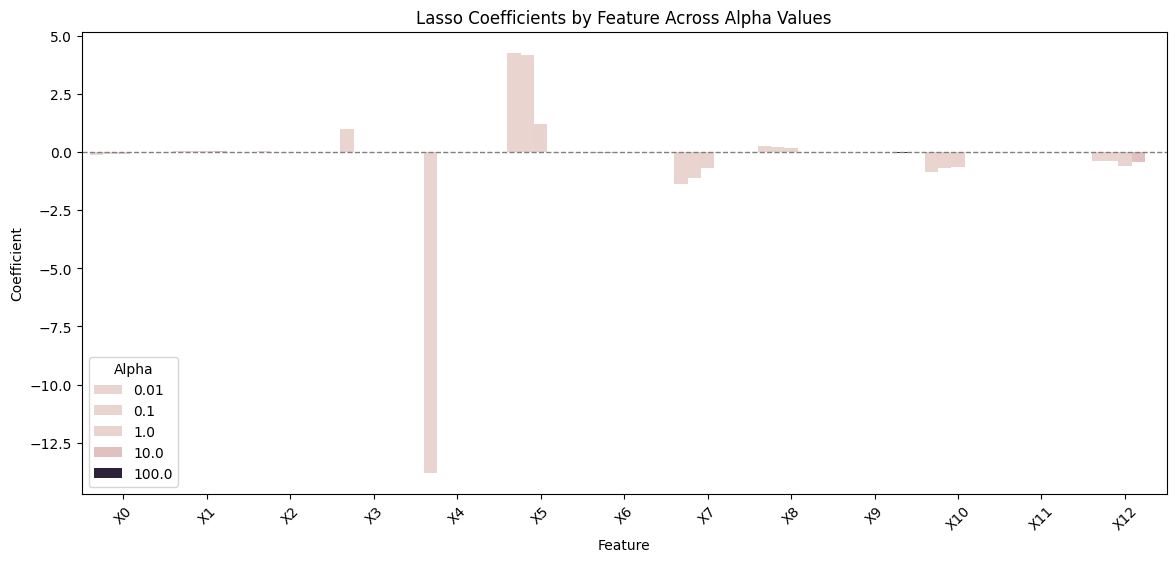

In [27]:
df_list = []
for i, coef in enumerate(coefficients):
    for j, c in enumerate(coef):
        df_list.append({'Alpha': alphas[i], 'Feature': f'X{j}', 'Coefficient': c})
df_plot = pd.DataFrame(df_list)

# Plot using seaborn
plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x="Feature", y="Coefficient", hue="Alpha")
plt.title("Lasso Coefficients by Feature Across Alpha Values")
plt.xticks(rotation=45)
plt.axhline(0, color='gray', linewidth=1, linestyle='--')

### <font color=blue>Answer this Question</font>

**How does increasing α in Lasso Regression influence the coefficients? How does it differ from Ridge Regression?**
  - Answer: Unlike Ridge regression, Lasso regression's coefficient goes to zero when alpha increases
  

#### b. Model Performance for Different α Values:
    
Evaluate the Lasso Regression model's performance for different α values using the R^2 and RMSE metrics.

In [30]:
# For each alpha value, predict using Lasso and calculate the R^2 and RMSE

# Create empty lists to store R^2 and RMSE scores for each alpha value tried.
r2_scores = []
rmse_scores = []


for a in alphas: #Loop through a list of alpha values
    lasso = Lasso(alpha=a)  #For each alpha, create a Ridge regression model with that alpha
    lasso.fit(X_train, y_train) #Fit it to the training data.
    y_pred = lasso.predict(X_test) #Use the fitted model to make predictions on the test data.
    
    r2_scores.append(r2_score(y_test, y_pred)) #Calculate R^2 and append to r2_scores list
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred))) #Calculate RMSE and append to rmse_scores list

# Print the scores for each alpha
for a, r2, rmse in zip(alphas, r2_scores, rmse_scores): #Loop through alphas, r2_scores and rmse_scores together. The zip() function packages them together into an iterator of tuples.
    print(f"For alpha = {a}, R^2 = {r2:.3f} and RMSE = {rmse:.3f}")




For alpha = 0.01, R^2 = 0.689 and RMSE = 5.390
For alpha = 0.1, R^2 = 0.670 and RMSE = 5.550
For alpha = 1, R^2 = 0.615 and RMSE = 5.993
For alpha = 10, R^2 = 0.406 and RMSE = 7.443
For alpha = 100, R^2 = 0.116 and RMSE = 9.079


### <font color=blue>Answer these Questions</font>

- **Which α value in Lasso Regression gives the highest R^2 score?**
  - Answer: 0.01
- **Which α value in Lasso Regression provides the lowest RMSE?**
  - Answer: 0.01
  
-**Given the results, which α value would you suggest for the Lasso model on this dataset? Why?**
  
  - Given higher R^2 and lower RMSE, alpha 0.01 model explains much better than other models  

Further Exploration (Optional):
    
- If you are interested, you could dive deeper into elastic net and compare its performance to ridge and lasso more extensively. Taking this extra step won't be graded, but it's a good way to deepen your understanding.

In [29]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Elastic Net with built-in cross-validation for alpha and l1_ratio
elastic_net = make_pipeline(
    StandardScaler(),
    ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], alphas=[0.01, 0.1, 1, 10, 100], cv=5)
)

# Fit the model
elastic_net.fit(X_train, y_train)

# Get best parameters
model = elastic_net.named_steps['elasticnetcv']
best_alpha = model.alpha_
best_l1_ratio = model.l1_ratio_
coefficients = model.coef_

Best Alpha: 0.1
Best L1 Ratio: 0.1
R^2 Score for Elastic Net: 0.6743286777012159
RMSE for Elastic Net: 5.51189533405508


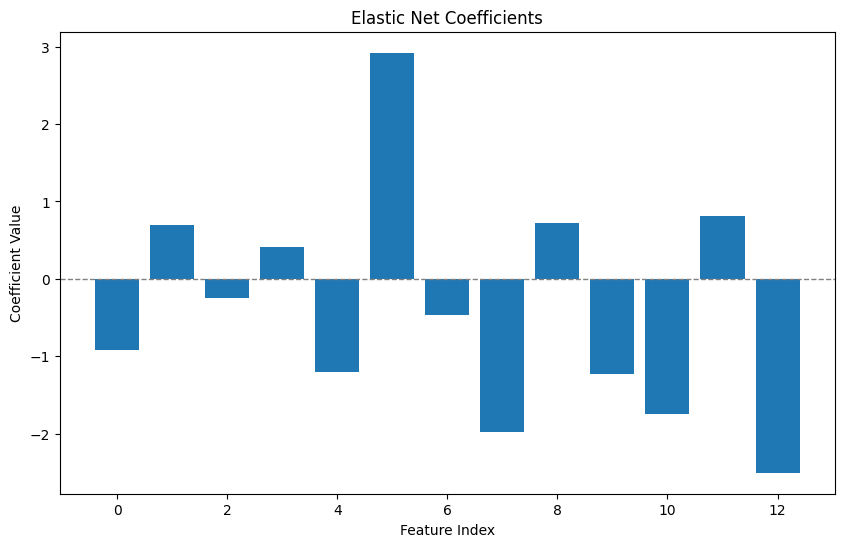

In [31]:
print(f"Best Alpha: {best_alpha}")
print(f"Best L1 Ratio: {best_l1_ratio}")

# Predict on the test set
y_pred_en = elastic_net.predict(X_test)
# Calculate the R^2 score and RMSE
r2_en = r2_score(y_test, y_pred_en)
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
print(f"R^2 Score for Elastic Net: {r2_en}")
print(f"RMSE for Elastic Net: {rmse_en}")
# Plot coefficients
plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients)), coefficients)
plt.title("Elastic Net Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.axhline(0, color='gray', linewidth=1, linestyle='--')
# Show the plot
plt.show()